In [1]:
!pip install opencv-python
!pip install numpy
!pip install pillow
!pip install matplotlib

Access is denied.
Access is denied.
Access is denied.
Access is denied.


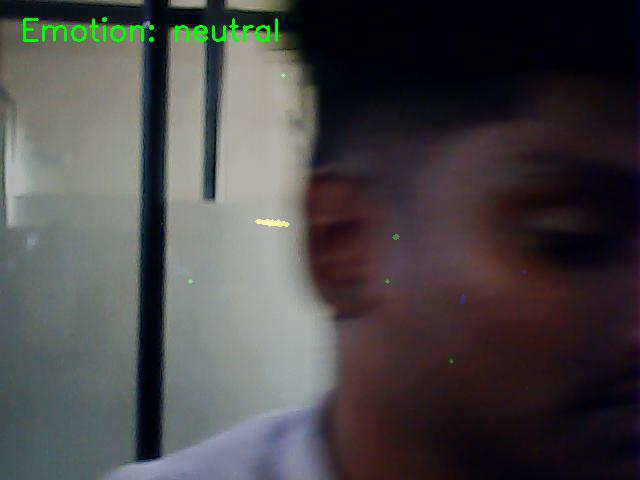

In [2]:
import cv2
import numpy as np
import io
from PIL import Image
import IPython.display as ipd

# -----------------------------
# Face detection
# -----------------------------
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

cap = cv2.VideoCapture(0)

canvas = None
prev_x, prev_y = 0, 0
emotion = "neutral"

colors = {
    "happy": (0, 255, 255),
    "sad": (255, 0, 0),
    "angry": (0, 0, 255),
    "neutral": (0, 255, 0)
}

print("Running Stable Emotion Paint (Fixed Display Issue)")

try:
    while True:

        ret, frame = cap.read()
        if not ret:
            break

        frame = cv2.flip(frame, 1)
        h, w, _ = frame.shape

        if canvas is None:
            canvas = np.zeros((h, w, 3), dtype=np.uint8)

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        faces = face_cascade.detectMultiScale(gray, 1.3, 5)

        # -----------------------------
        # SIMPLE EMOTION LOGIC
        # -----------------------------
        if len(faces) > 0:
            x, y, fw, fh = faces[0]

            if fh / w > 0.30:
                emotion = "happy"
            elif fh / w > 0.20:
                emotion = "sad"
           
            else:
                emotion = "neutral"

            cx, cy = x + fw // 2, y + fh // 2
            color = colors[emotion]

            cv2.circle(frame, (cx, cy), 10, color, -1)

            if prev_x == 0:
                prev_x, prev_y = cx, cy

            cv2.line(canvas, (prev_x, prev_y), (cx, cy), color, 4)

            prev_x, prev_y = cx, cy

        else:
            prev_x, prev_y = 0, 0
            emotion = "neutral"

        # -----------------------------
        # Merge canvas
        # -----------------------------
        frame = cv2.addWeighted(frame, 0.7, canvas, 0.3, 0)

        cv2.putText(frame, f"Emotion: {emotion}", (20, 40),
                    cv2.FONT_HERSHEY_SIMPLEX, 1,
                    colors[emotion], 2)

        # -----------------------------
        # JUPYTER DISPLAY FIX
        # -----------------------------
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        img = Image.fromarray(rgb)

        buffer = io.BytesIO()
        img.save(buffer, format="JPEG")

        ipd.clear_output(wait=True)
        ipd.display(ipd.Image(data=buffer.getvalue()))

except KeyboardInterrupt:
    print("Stopped safely")

finally:
    cap.release()
    cv2.destroyAllWindows()